In [1]:
# imports
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
import warnings

In [2]:
## FINAL FEATURE SELECTION

feats = ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HPTS%', 'HSOW', 'HSRS', 'HSOS', 'HGF/G', 
         'HGA/G', 'HPP', 'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HS%', 'HSV%', 
         'HSO', 'HCAN', 'VRk', 'VAvAge', 'VL', 'VPP', 'VPPO', 'VSH', 'VPIM/G', 'VoPIM/G', 
         'VS%', 'VSV%', 'MDAY', 'TDAY', 'WDAY', 'ThDAY', 'FDAY', 'SDAY', 'SuDAY', 'DIV', 'CAP', 
         'LCAP', 'HSTAR']

In [3]:
# load data
df_att_all = pd.read_csv('attendance data with features.csv')

# only feature selection
df_att = df_att_all[['A', 'PA', 'LA'] + feats]

# Set random seed
rand_seed = 34

In [4]:
# Define models
models = {
    "OLS": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# regularization parameters
# optimal values for l1_alpha found in Data Feature Selection
lasso_A = 3.59
lasso_LA = 0.000129
lasso_PA = 0.000279

ridge_A = 0.5
ridge_LA = 0.1
ridge_PA = 0.1

# Define model parameters for each dependent variable type
model_params = {
    "A": {
        "OLS": {},
        "Lasso": {'alpha': lasso_A},
        "Ridge": {'alpha': ridge_A},
        "ElasticNet": {
            'alpha': (lasso_A + ridge_A) * 0.25,  # Sum of Lasso and Ridge alphas, multiplied by 0.25 to avoid over-regularization
            'l1_ratio': lasso_A / (lasso_A + ridge_A)  # Ratio based on Lasso strength
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': rand_seed}
    },
    "LA": {
        "OLS": {},
        "Lasso": {'alpha': lasso_LA},
        "Ridge": {'alpha': ridge_LA},
        "ElasticNet": {
            'alpha': (lasso_LA + ridge_LA) * 0.25,
            'l1_ratio': lasso_LA / (lasso_LA + ridge_LA)
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 200, 'learning_rate': 0.1, 'random_state': rand_seed}
    },
    "PA": {
        "OLS": {},
        "Lasso": {'alpha': lasso_PA},
        "Ridge": {'alpha': ridge_PA},
        "ElasticNet": {
            'alpha': (lasso_PA + ridge_PA) * 0.25,
            'l1_ratio': lasso_PA / (lasso_PA + ridge_PA)
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': rand_seed}
    }
}

In [5]:
# Function to compute evaluation metrics with dependent variable transformation
def compute_stats(dep, X_train, X_test, y_train, y_train_pred, y_test, y_test_pred):
    if dep == 'A':
        y_train_true, y_train_pred = y_train, y_train_pred
        y_test_true, y_test_pred = y_test, y_test_pred

    elif dep == 'LA':
        y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
        y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)

    elif dep == 'PA':
        y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
        y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']

    return {
        "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
        "R² Train": r2_score(y_train_true, y_train_pred),
        "RMSE Test": sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "MAE Test": mean_absolute_error(y_test_true, y_test_pred),
        "R² Test": r2_score(y_test_true, y_test_pred)
    }

In [6]:
def run_model(model, model_name, X_train, X_test, y_train, y_test, dep, model_params):
    # Select the correct parameters for the given dep
    params = model_params[dep].get(model_name)

    # If the model is 'Lasso', 'ElasticNet', or 'Ridge', scale the features
    if model_name in ["Lasso", "ElasticNet"]:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.set_params(**params)  # Set the parameters for the model
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.set_params(**params)  # Set the parameters for the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    return {"Model": model_name, **compute_stats(dep, X_train, X_test, y_train, y_train_pred, y_test, y_test_pred)}

In [7]:
def plot_predict(models, X_train, X_test, y_train, y_test, dep, model_params):    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Plot actual vs. predicted for each model
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(models.items()):
        # Select the correct parameters for the given dep
        params = model_params[dep].get(name)
        
        # Fit and predict for the model
        if name in ["Lasso", "ElasticNet"]:
            # Scale features for Lasso and ElasticNet
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            model.set_params(**params)  # Set the parameters
            model.fit(X_train_scaled, y_train)
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)
        else:
            model.set_params(**params)  # Set the parameters
            model.fit(X_train, y_train)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

        # Apply dependent variable transformations and plot accordingly
        if dep == 'LA':
            y_test_la = np.exp(y_test)
            y_test_pred_la = np.exp(y_test_pred)

            ax = axes[i]
            ax.scatter(y_test_la, y_test_pred_la, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test_la), max(y_test_la)], [min(y_test_la), max(y_test_la)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Log-Transformed)")
            ax.set_xlabel("Actual Attendance (Log)")
            ax.set_ylabel("Predicted Attendance (Log)")

        elif dep == 'PA':
            y_test_pa = y_test * X_test['CAP']
            y_test_pred_pa = y_test_pred * X_test['CAP']

            ax = axes[i]
            ax.scatter(y_test_pa, y_test_pred_pa, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test_pa), max(y_test_pa)], [min(y_test_pa), max(y_test_pa)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Capacity Adjusted)")
            ax.set_xlabel("Actual Attendance (Capacity Adjusted)")
            ax.set_ylabel("Predicted Attendance (Capacity Adjusted)")

        else:
            ax = axes[i]
            ax.scatter(y_test, y_test_pred, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Original)")
            ax.set_xlabel("Actual Attendance")
            ax.set_ylabel("Predicted Attendance")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

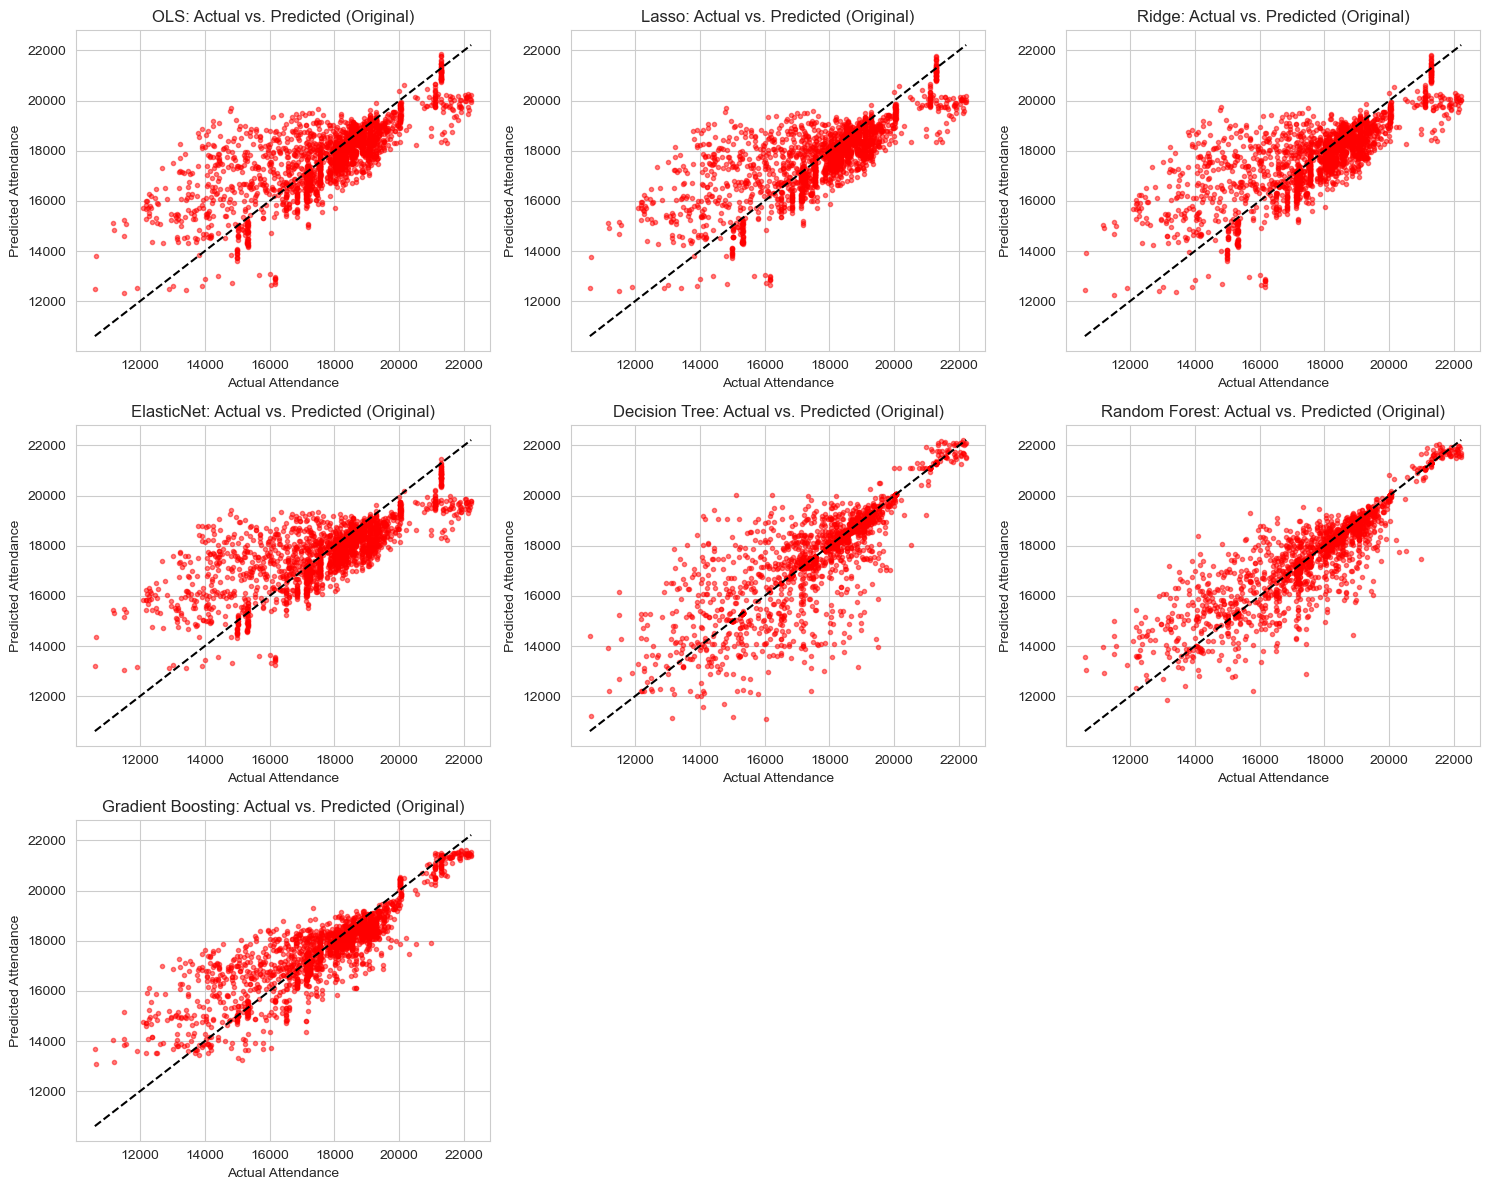

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1285.455880,906.976446,0.543464,1293.432470,914.672458,0.560175
1,Lasso,1287.373587,908.104369,0.542101,1296.516098,918.584188,0.558076
2,Ridge,1287.285848,908.521074,0.542163,1295.454387,917.490730,0.558799
3,ElasticNet,1307.412533,923.230288,0.527735,1317.061045,938.460148,0.543959
4,Decision Tree,298.217666,123.541939,0.975429,1160.478330,649.556624,0.645949
5,Random Forest,342.776639,198.364827,0.967537,901.863255,533.220127,0.786168
6,Gradient Boosting,898.517032,613.094498,0.776944,957.258190,653.919735,0.759093


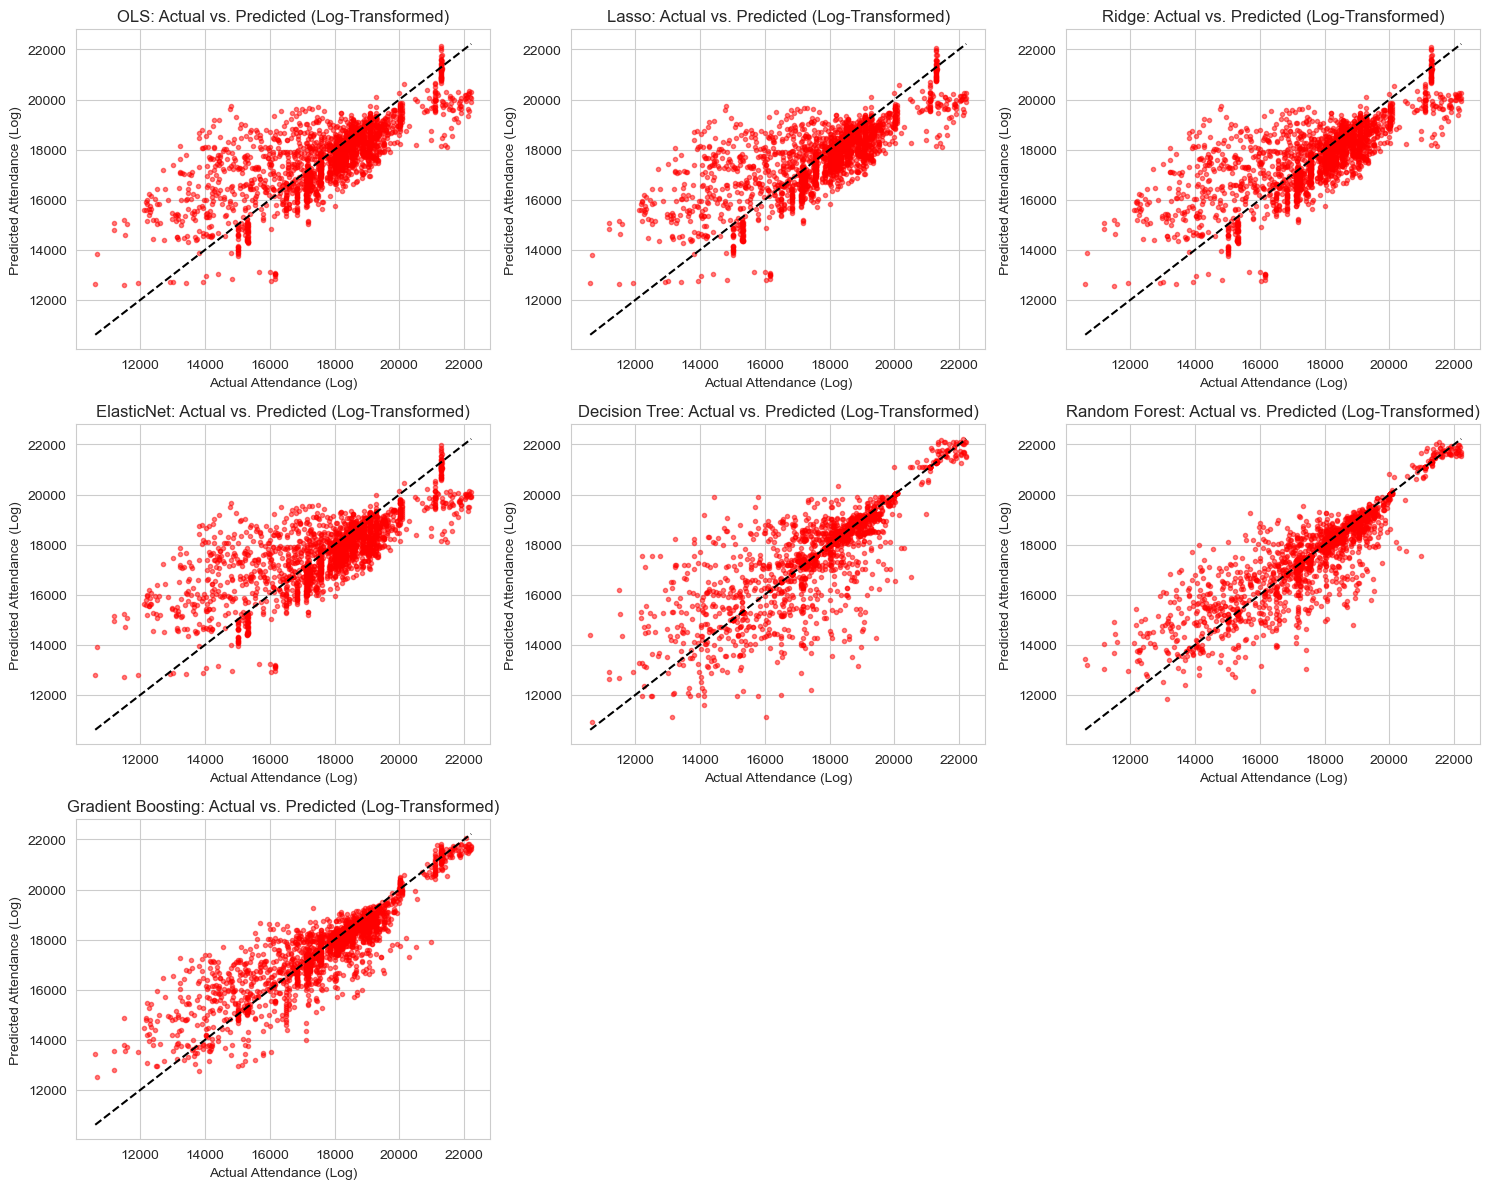

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1289.125143,929.603451,0.540854,1294.269230,935.189857,0.559606
1,Lasso,1289.835158,930.543910,0.540348,1295.765764,937.578217,0.558587
2,Ridge,1289.083416,929.393641,0.540884,1294.333129,935.656942,0.559563
3,ElasticNet,1293.286340,932.876034,0.537885,1299.501024,941.283985,0.556039
4,Decision Tree,387.175189,170.437340,0.958583,1164.153047,654.608934,0.643703
5,Random Forest,343.996068,199.590656,0.967306,894.776455,529.560189,0.789515
6,Gradient Boosting,809.985011,550.792225,0.818735,901.573864,604.486848,0.786305


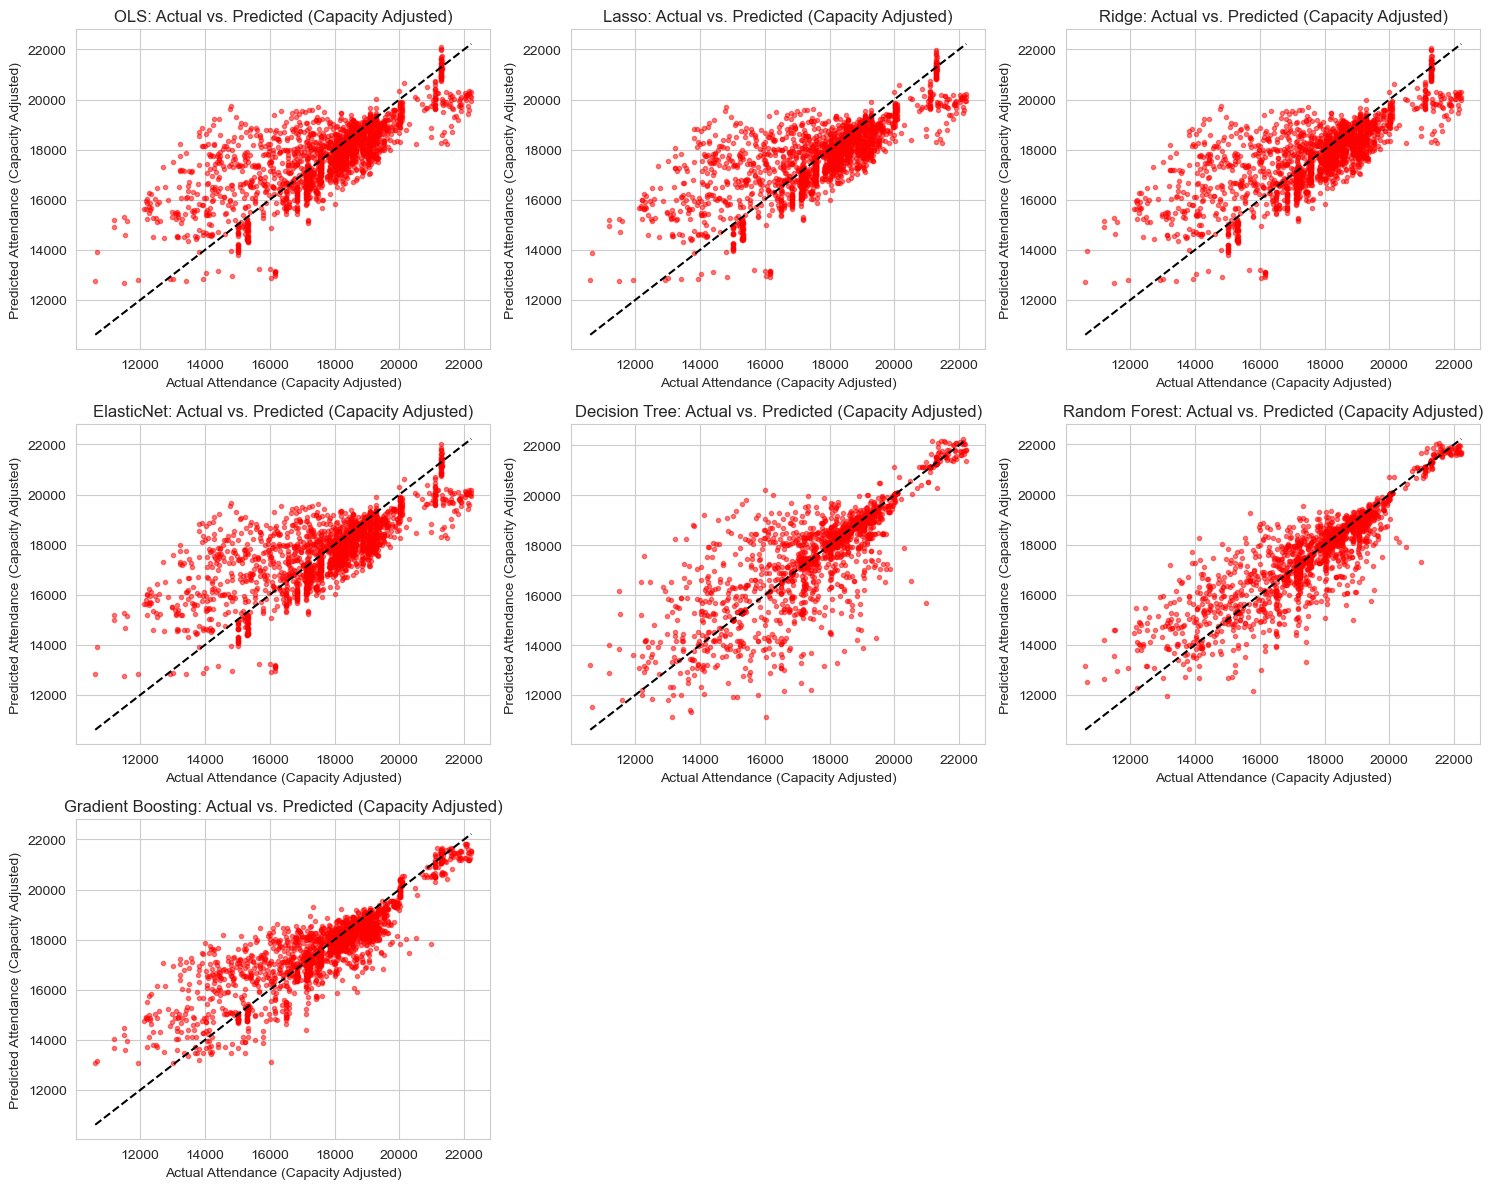

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1285.953408,909.273784,0.543110,1293.500188,916.481205,0.560129
1,Lasso,1289.394476,910.925200,0.540662,1298.930716,921.752958,0.556428
2,Ridge,1285.982839,909.038479,0.543089,1293.668754,916.847405,0.560015
3,ElasticNet,1290.479696,912.064544,0.539888,1299.691521,922.738908,0.555908
4,Decision Tree,359.703288,149.710601,0.964252,1157.965742,651.110368,0.647480
5,Random Forest,343.287857,199.284635,0.967441,888.870425,529.384463,0.792285
6,Gradient Boosting,910.531806,619.797897,0.770939,966.452297,659.839788,0.754443


In [8]:
# Dependent variable
deps = ['A', 'LA', 'PA']

for dep in deps:
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])

    y = df_att[dep]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

    results = [run_model(model, name, X_train, X_test, y_train, y_test, dep, model_params) for name, model in models.items()]
    df_results = pd.DataFrame(results)

    plot_predict(models, X_train, X_test, y_train, y_test, dep, model_params)

    display(df_results)

In [9]:
def kfold_cv(model, model_name, X, y, dep, model_params, n_splits=5):
    kf = KFold(n_splits=n_splits)#, shuffle=True, random_state=rand_seed)
    results = []

    # Set model parameters if available
    params = model_params.get(dep, {}).get(model_name, {})
    
    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Extract the 'CAP' column before scaling if it's present
        cap_train = X_train['CAP'] if 'CAP' in X_train.columns else None
        cap_val = X_val['CAP'] if 'CAP' in X_val.columns else None

        # Scaling for Lasso and ElasticNet
        if model_name in ["Lasso", "ElasticNet"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

        # Initialize model with the parameters from model_params (if any)
        if params:
            model.set_params(**params)

        # Fit the model
        # model.fit(X_train, y_train)

        # Fit the model with warning capture
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_train, y_train)
            
            # Print convergence warnings with context
            for warning in w:
                if issubclass(warning.category, ConvergenceWarning):
                    print(f"⚠️ Convergence warning during {model_name} on {dep}: {warning.message}")
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Apply dependent variable transformation based on `dep`
        if dep == 'A':
            y_train_true, y_train_pred = y_train, y_train_pred
            y_val_true, y_val_pred = y_val, y_val_pred
        elif dep == 'LA':
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_val_true, y_val_pred = np.exp(y_val), np.exp(y_val_pred)
        elif dep == 'PA':
            if cap_train is not None:
                y_train_true, y_train_pred = y_train * cap_train, y_train_pred * cap_train
                y_val_true, y_val_pred = y_val * cap_val, y_val_pred * cap_val
            else:
                raise ValueError("CAP column is missing in the dataset.")

        # Compute evaluation metrics
        metrics = {
            "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
            "R² Train": r2_score(y_train_true, y_train_pred),
            "RMSE Test": sqrt(mean_squared_error(y_val_true, y_val_pred)),
            "MAE Test": mean_absolute_error(y_val_true, y_val_pred),
            "R² Test": r2_score(y_val_true, y_val_pred)
        }

        results.append(metrics)

    # Convert results to DataFrame and compute average scores
    results_df = pd.DataFrame(results)
    avg_scores = results_df.mean().to_dict()
    avg_scores["Model"] = model_name  # Add model name for reference

    return avg_scores

In [10]:
# Dependent variable
deps = ['A', 'LA', 'PA']

for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1274.655053,905.370282,0.554918,1430.622724,1047.425188,0.423868,OLS
1,1277.211903,906.832998,0.553123,1416.752836,1038.221516,0.434584,Lasso
2,1277.008573,906.813394,0.553299,1421.259184,1039.710952,0.432168,Ridge
3,1298.616281,922.430279,0.538022,1411.148255,1038.238584,0.439260,ElasticNet
4,345.444079,147.448199,0.967068,1567.396876,970.689739,0.276164,Decision Tree
5,349.724871,199.782846,0.966459,1162.111577,771.552332,0.608775,Random Forest
6,893.600904,608.252368,0.780880,1195.625842,860.471269,0.591655,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1278.746489,927.451225,0.552044,1439.281652,1071.600182,0.415851,OLS
1,1279.900976,928.583959,0.551224,1425.577030,1062.734968,0.426461,Lasso
2,1278.743674,927.219792,0.552046,1434.234231,1067.474289,0.420439,Ridge
3,1283.833445,931.375433,0.548460,1422.750910,1063.658916,0.429156,ElasticNet
4,381.926456,170.751493,0.960005,1516.431322,960.071806,0.322255,Decision Tree
5,349.328189,200.067154,0.966536,1209.007715,798.195959,0.570864,Random Forest
6,806.189459,546.950672,0.821654,1226.820996,887.973887,0.566529,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1275.372933,907.522906,0.554399,1426.000268,1044.725727,0.427140,OLS
1,1279.563296,909.914441,0.551462,1409.373985,1034.111685,0.439914,Lasso
2,1275.486584,907.163375,0.554322,1421.327830,1040.714977,0.431340,Ridge
3,1280.876709,910.764743,0.550533,1408.915724,1035.820388,0.440455,ElasticNet
4,449.066961,200.473546,0.944004,1657.882648,1058.929709,0.212387,Decision Tree
5,349.497561,199.493523,0.966509,1256.961421,851.887107,0.541881,Random Forest
6,908.817195,616.797126,0.773535,1200.294249,861.961850,0.588898,Gradient Boosting


In [11]:
# Define Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': ['sqrt', 'log2', None]
}

# Define Gradient Boosting hyperparameter grid
gb_param_grid = {
    'subsample': [0.5, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize models
rf = RandomForestRegressor(random_state=rand_seed)
gb = GradientBoostingRegressor(random_state=rand_seed)

# Initialize RandomizedSearchCV with TimeSeriesSplit
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

In [12]:
# Initialize an empty dictionary to store the best parameters
best_params = {}

for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Fit Random Forest model
    rf_random_search.fit(X, y)
    best_params[f"RandomForest_{dep}"] = rf_random_search.best_params_

    print(f'done RF for {dep}')
    
    # Fit Gradient Boosting model
    gb_random_search.fit(X, y)
    best_params[f"GradientBoosting_{dep}"] = gb_random_search.best_params_

    print(f'done XGBoost for {dep}')

# Create a DataFrame from the best_params dictionary
best_params_df = pd.DataFrame.from_dict(best_params, orient='index')

# Replace NaN values with '-' for better readability
best_params_df = best_params_df.fillna('-')

# Display the DataFrame
print("\nBest Parameters DataFrame:")
display(best_params_df)

done RF for A
done XGBoost for A
done RF for LA
done XGBoost for LA
done RF for PA
done XGBoost for PA

Best Parameters DataFrame:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,subsample,learning_rate
RandomForest_A,200,20,5,-,-,-,-
GradientBoosting_A,100,2,5,-,10.0,0.7,0.05
RandomForest_LA,200,20,5,-,-,-,-
GradientBoosting_LA,50,10,10,-,5.0,0.7,0.2
RandomForest_PA,50,10,5,sqrt,30.0,-,-
GradientBoosting_PA,100,2,1,-,3.0,0.7,0.2


In [13]:
# column names
columns = ["Dep", "Model", "RMSE Train", "MAE Train", "R² Train", "RMSE Test", "MAE Test", "R² Test"]

# initialize results list
results_list = []

# Loop through dependent variables and apply the best model for each
for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:  # For 'LA'
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on dependent variable
    rf_params = best_params[f"RandomForest_{dep}"]
    gb_params = best_params[f"GradientBoosting_{dep}"]

    # Train and evaluate both models
    for model_name, model_params, model_class in [
        ("Random Forest", rf_params, RandomForestRegressor),
        ("Gradient Boosting", gb_params, GradientBoostingRegressor)
    ]:
        # Instantiate the model with optimized hyperparameters
        model = model_class(random_state=rand_seed, **model_params)

        # Fit the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # **Adjust predictions based on dependent variable transformation**
        if dep == 'LA':  # Log Attendance was used → Apply exp()
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)
        elif dep == 'PA':  # Percentage Attendance → Multiply by CAP
            y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
            y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']
        else:  # 'A' (Raw Attendance) → No adjustment needed
            y_train_true, y_train_pred = y_train, y_train_pred
            y_test_true, y_test_pred = y_test, y_test_pred

        # Compute evaluation metrics
        rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        mae_train = mean_absolute_error(y_train_true, y_train_pred)
        r2_train = r2_score(y_train_true, y_train_pred)

        rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        mae_test = mean_absolute_error(y_test_true, y_test_pred)
        r2_test = r2_score(y_test_true, y_test_pred)

        # Store results in a list
        results_list.append({
            "Dep": dep,
            "Model": model_name,
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "R² Train": r2_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
            "R² Test": r2_test
        })

        # Scatter plot for actual vs predicted values
        fig, ax = plt.subplots(figsize=(6, 6))  # Define figure size
        ax.scatter(y_test_true, y_test_pred, alpha=0.5, color='red', marker='.', s=10)
        ax.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 
                color='black', linestyle='--', label="Ideal Fit")  # Ideal fit line
        ax.set_title(f"{model_name} Optimized: Actual vs. Predicted ({dep})")
        ax.set_xlabel("Actual Attendance")
        ax.set_ylabel("Predicted Attendance")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        plt.savefig(f"kfold_{model_name}_{dep}_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
        plt.close()

# Convert list to DataFrame
df_results = pd.DataFrame(results_list)[columns]

# Display results table
df_results

,Dep,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,A,Random Forest,668.098941,398.160007,0.878222,862.815651,507.140644,0.794356
1,A,Gradient Boosting,443.360990,275.740806,0.946371,855.448425,509.609678,0.797853
2,LA,Random Forest,672.794587,401.598751,0.876504,867.910018,509.845672,0.791920
3,LA,Gradient Boosting,734.781127,491.600431,0.852700,881.895708,570.172301,0.785160
4,PA,Random Forest,704.706206,420.791038,0.864511,884.436336,518.821527,0.783920
5,PA,Gradient Boosting,809.800162,543.614345,0.821086,903.617208,592.190194,0.774446


In [14]:
### TIME SERIES CROSS VALIDATION

def time_series_cv(model, model_name, X, y, dep, model_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    # Set model parameters if available
    params = model_params.get(dep, {}).get(model_name, {})
    
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Extract the 'CAP' column before scaling if it's present
        cap_train = X_train['CAP'] if 'CAP' in X_train.columns else None
        cap_val = X_val['CAP'] if 'CAP' in X_val.columns else None

        # Scaling for Lasso and ElasticNet
        if model_name in ["Lasso", "ElasticNet"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

        # Initialize model with the parameters from model_params (if any)
        if params:
            model.set_params(**params)

        # Fit the model
        #model.fit(X_train, y_train)

        # Fit the model with warning capture
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_train, y_train)
            
            # Print convergence warnings with context
            for warning in w:
                if issubclass(warning.category, ConvergenceWarning):
                    print(f"⚠️ Convergence warning during {model_name} on {dep}: {warning.message}")
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Apply dependent variable transformation based on `dep`
        if dep == 'A':
            y_train_true, y_train_pred = y_train, y_train_pred
            y_val_true, y_val_pred = y_val, y_val_pred
        elif dep == 'LA':
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_val_true, y_val_pred = np.exp(y_val), np.exp(y_val_pred)
        elif dep == 'PA':
            if cap_train is not None:
                y_train_true, y_train_pred = y_train * cap_train, y_train_pred * cap_train
                y_val_true, y_val_pred = y_val * cap_val, y_val_pred * cap_val
            else:
                raise ValueError("CAP column is missing in the dataset.")

        # Compute evaluation metrics
        metrics = {
            "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
            "R² Train": r2_score(y_train_true, y_train_pred),
            "RMSE Test": sqrt(mean_squared_error(y_val_true, y_val_pred)),
            "MAE Test": mean_absolute_error(y_val_true, y_val_pred),
            "R² Test": r2_score(y_val_true, y_val_pred)
        }

        results.append(metrics)

    # Convert results to DataFrame and compute average scores
    results_df = pd.DataFrame(results)
    avg_scores = results_df.mean().to_dict()
    avg_scores["Model"] = model_name  # Add model name for reference

    return avg_scores

In [15]:
# Dependent variable
deps = ['A', 'LA', 'PA']  # Change to 'LA' or 'PA' if needed

for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Run all models with TimeSeriesSplit CV
    cv_results = [time_series_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.089e+09, tolerance: 7.354e+05
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.453e+09, tolerance: 1.434e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.023e+09, tolerance: 2.157e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.534e+09, tolerance: 2.752e+06
⚠️ Convergence warning during Lasso on A: Ob

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1230.307155,877.906613,0.628198,1410.035281,1029.975724,0.414070,OLS
1,1230.604840,877.426630,0.628037,1404.457342,1024.423661,0.417854,Lasso
2,1236.904443,875.306581,0.624501,1394.136515,1010.220829,0.427059,Ridge
3,1242.955049,879.337845,0.620980,1377.452388,995.853123,0.439642,ElasticNet
4,313.837261,124.413448,0.973229,1604.165567,1051.333997,0.244730,Decision Tree
5,354.873317,197.458340,0.969266,1227.439277,858.790315,0.558238,Random Forest
6,825.375662,543.992536,0.832511,1212.886388,882.294319,0.563664,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1236.260529,902.204177,0.624680,1431.499625,1065.448038,0.397008,OLS
1,1243.383772,899.911865,0.620667,1395.187557,1028.459448,0.425333,Lasso
2,1241.204621,899.985388,0.621952,1409.066075,1042.210563,0.415106,Ridge
3,1248.612900,903.451116,0.617563,1389.995605,1025.631127,0.430062,ElasticNet
4,304.089079,116.220072,0.975747,1744.663557,1148.027429,0.100161,Decision Tree
5,354.422534,197.819963,0.969340,1250.673446,886.165423,0.535604,Random Forest
6,823.670097,551.857265,0.833164,1208.778580,881.463300,0.564655,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1230.288619,880.789088,0.628209,1417.270796,1037.509931,0.408719,OLS
1,1239.951842,879.711553,0.622715,1385.559503,1003.920192,0.433507,Lasso
2,1236.051585,878.073148,0.625016,1398.933738,1016.045394,0.423613,Ridge
3,1243.678184,880.791420,0.620529,1381.545553,1000.427846,0.436887,ElasticNet
4,325.145569,123.015002,0.971922,1846.654535,1240.573053,-0.003789,Decision Tree
5,354.547394,197.078282,0.969320,1315.593230,924.159684,0.489416,Random Forest
6,831.784156,548.369071,0.829399,1255.331908,901.122777,0.537625,Gradient Boosting


In [16]:
# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Define Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': ['sqrt', 'log2', None]
}

# Define Gradient Boosting hyperparameter grid
gb_param_grid = {
    'subsample': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [50, 100, 200, 500, 750],
    'learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [1, 2, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize models
rf = RandomForestRegressor(random_state=rand_seed)
gb = GradientBoostingRegressor(random_state=rand_seed)

# Initialize RandomizedSearchCV with TimeSeriesSplit
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=tscv,  # Use TimeSeriesSplit
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

In [17]:
# Initialize an empty dictionary to store the best parameters
best_params = {}

for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Fit Random Forest model
    rf_random_search.fit(X, y)
    best_params[f"RandomForest_{dep}"] = rf_random_search.best_params_

    print(f'done RF for {dep}')
    
    # Fit Gradient Boosting model
    gb_random_search.fit(X, y)
    best_params[f"GradientBoosting_{dep}"] = gb_random_search.best_params_

    print(f'done XGBoost for {dep}')

# Create a DataFrame from the best_params dictionary
best_params_df = pd.DataFrame.from_dict(best_params, orient='index')

# Replace NaN values with '-' for better readability
best_params_df = best_params_df.fillna('-')

# Display the DataFrame
print("\nBest Parameters DataFrame:")
display(best_params_df)

done RF for A
done XGBoost for A
done RF for LA
done XGBoost for LA
done RF for PA
done XGBoost for PA

Best Parameters DataFrame:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,subsample,learning_rate
RandomForest_A,200,20,5,-,-,-,-
GradientBoosting_A,500,2,10,-,5.0,0.6,0.01
RandomForest_LA,200,20,5,-,-,-,-
GradientBoosting_LA,500,2,10,-,5.0,0.6,0.01
RandomForest_PA,750,10,5,log2,10.0,-,-
GradientBoosting_PA,500,2,10,-,5.0,0.6,0.01


In [18]:
# column names
columns = ["Dep", "Model", "RMSE Train", "MAE Train", "R² Train", "RMSE Test", "MAE Test", "R² Test"]

# initialize results list
results_list = []

# Loop through dependent variables and apply the best model for each
for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:  # For 'LA'
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on dependent variable
    rf_params = best_params[f"RandomForest_{dep}"]
    gb_params = best_params[f"GradientBoosting_{dep}"]

    # Train and evaluate both models
    for model_name, model_params, model_class in [
        ("Random Forest", rf_params, RandomForestRegressor),
        ("Gradient Boosting", gb_params, GradientBoostingRegressor)
    ]:
        # Instantiate the model with optimized hyperparameters
        model = model_class(random_state=rand_seed, **model_params)

        # Fit the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # **Adjust predictions based on dependent variable transformation**
        if dep == 'LA':  # Log Attendance was used → Apply exp()
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)
        elif dep == 'PA':  # Percentage Attendance → Multiply by CAP
            y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
            y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']
        else:  # 'A' (Raw Attendance) → No adjustment needed
            y_train_true, y_train_pred = y_train, y_train_pred
            y_test_true, y_test_pred = y_test, y_test_pred

        # Compute evaluation metrics
        rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        mae_train = mean_absolute_error(y_train_true, y_train_pred)
        r2_train = r2_score(y_train_true, y_train_pred)

        rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        mae_test = mean_absolute_error(y_test_true, y_test_pred)
        r2_test = r2_score(y_test_true, y_test_pred)

        # Store results in a list
        results_list.append({
            "Dep": dep,
            "Model": model_name,
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "R² Train": r2_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
            "R² Test": r2_test
        })

        # Scatter plot for actual vs predicted values
        fig, ax = plt.subplots(figsize=(6, 6))  # Define figure size
        ax.scatter(y_test_true, y_test_pred, alpha=0.5, color='red', marker='.', s=10)
        ax.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 
                color='black', linestyle='--', label="Ideal Fit")  # Ideal fit line
        ax.set_title(f"{model_name} Optimized: Actual vs. Predicted ({dep})")
        ax.set_xlabel("Actual Attendance")
        ax.set_ylabel("Predicted Attendance")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        plt.savefig(f"time_series_{model_name}_{dep}_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
        plt.close()
        
# Convert list to DataFrame
df_results = pd.DataFrame(results_list)[columns]

# Display results table
df_results

,Dep,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,A,Random Forest,668.098941,398.160007,0.878222,862.815651,507.140644,0.794356
1,A,Gradient Boosting,809.734852,535.439818,0.821115,895.450213,581.545477,0.778505
2,LA,Random Forest,672.794587,401.598751,0.876504,867.910018,509.845672,0.791920
3,LA,Gradient Boosting,809.608244,545.059961,0.821171,898.440514,591.848396,0.777023
4,PA,Random Forest,819.322466,526.513551,0.816854,916.908953,571.176662,0.767762
5,PA,Gradient Boosting,828.975257,553.413453,0.812513,914.881432,598.631918,0.768788


In [19]:
# Try with not using the arizona coyotes --> inconsistent data and might be irrelevant
# remove coyotes (home team only)
df_att_no_coyotes_home = df_att.loc[df_att_all['H'] != 'Arizona Coyotes']
df_att_no_coyotes = df_att.loc[(df_att_all['H'] != 'Arizona Coyotes') & (df_att_all['V'] != 'Arizona Coyotes')]

# Dependent variable
deps = ['A', 'LA', 'PA']

print('No Arizona Coyotes Home Games')
for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att_no_coyotes_home.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att_no_coyotes_home.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att_no_coyotes_home[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

print('\nNo Arizona Coyotes Home and Visitor Games')
for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att_no_coyotes.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att_no_coyotes.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att_no_coyotes[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

No Arizona Coyotes Home Games
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.312e+09, tolerance: 2.722e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.245e+09, tolerance: 2.756e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.278e+09, tolerance: 2.792e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.951e+09, tolerance: 2.846e+06
⚠️ Convergence

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.490867,877.049482,0.553851,1390.613227,1007.667795,0.430299,OLS
1,1245.549933,877.238211,0.553808,1388.495307,1005.638895,0.431904,Lasso
2,1245.855742,877.016613,0.553594,1387.015197,1004.453872,0.433504,Ridge
3,1250.296237,878.779344,0.550384,1374.114396,998.158587,0.443304,ElasticNet
4,347.962045,147.342189,0.964977,1546.801945,960.523362,0.254562,Decision Tree
5,346.385103,196.201154,0.965452,1172.322952,783.882680,0.582113,Random Forest
6,881.103686,595.402619,0.776483,1195.734839,857.629916,0.571355,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1248.773509,897.061906,0.551481,1397.412613,1029.166920,0.424280,OLS
1,1251.550481,897.013676,0.549471,1378.491037,1014.935961,0.439228,Lasso
2,1248.791838,896.859663,0.551469,1392.926637,1025.334935,0.428258,Ridge
3,1254.351870,899.219138,0.547450,1380.030220,1018.682493,0.438281,ElasticNet
4,372.618474,164.030776,0.960001,1580.642147,991.314477,0.231587,Decision Tree
5,345.589779,196.294473,0.965616,1203.257018,804.191749,0.553513,Random Forest
6,877.701952,604.738798,0.778248,1198.009350,869.623377,0.568864,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.756595,878.036056,0.553644,1385.516362,1003.809650,0.434161,OLS
1,1249.970823,878.305669,0.550608,1368.320028,990.822101,0.447425,Lasso
2,1245.855613,877.769644,0.553575,1381.426478,1000.241318,0.437753,Ridge
3,1251.532925,879.504983,0.549478,1368.576750,993.456735,0.447385,ElasticNet
4,437.470270,195.688204,0.943276,1641.242872,1039.809379,0.178350,Decision Tree
5,343.803099,194.679715,0.965977,1222.346646,825.968293,0.539795,Random Forest
6,886.317187,598.658666,0.773845,1182.439948,844.501545,0.581535,Gradient Boosting



No Arizona Coyotes Home and Visitor Games
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.147e+09, tolerance: 2.642e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.053e+09, tolerance: 2.685e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.063e+09, tolerance: 2.699e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.799e+09, tolerance: 2.767e+06
⚠

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.350858,876.291035,0.554157,1385.165751,1001.981019,0.434831,OLS
1,1245.410550,876.510690,0.554114,1383.087708,1000.038860,0.436389,Lasso
2,1245.738807,876.238189,0.553884,1381.524029,998.717869,0.438075,Ridge
3,1250.130569,878.023429,0.550712,1368.853264,993.028384,0.447604,ElasticNet
4,344.137276,145.923155,0.965750,1554.320879,981.579216,0.261318,Decision Tree
5,346.921225,196.778899,0.965359,1170.181757,786.372795,0.583114,Random Forest
6,878.277222,593.683602,0.777987,1196.708151,854.806714,0.571381,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1248.623045,896.331580,0.551798,1391.985939,1023.393081,0.428728,OLS
1,1251.454150,896.357566,0.549750,1373.427490,1009.754863,0.443248,Lasso
2,1248.658664,896.094205,0.551774,1387.453026,1019.514200,0.432741,Ridge
3,1254.192589,898.442732,0.547775,1374.766687,1013.385913,0.442526,ElasticNet
4,364.464127,158.648547,0.961751,1553.589554,978.066887,0.239686,Decision Tree
5,345.471767,196.374997,0.965649,1189.928174,793.525987,0.562266,Random Forest
6,875.323448,602.119993,0.779534,1197.722606,863.251913,0.568031,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.589574,877.255045,0.553971,1380.205364,998.189145,0.438500,OLS
1,1249.829449,877.526949,0.550918,1363.458576,985.868443,0.451282,Lasso
2,1245.705251,876.966711,0.553892,1376.059331,994.486839,0.442138,Ridge
3,1251.354607,878.646385,0.549816,1363.412628,988.339723,0.451537,ElasticNet
4,390.306851,172.447270,0.955172,1517.970510,954.362506,0.286698,Decision Tree
5,343.343693,194.154555,0.966075,1202.264380,814.543629,0.558646,Random Forest
6,887.780525,598.096050,0.773195,1177.619692,839.955945,0.584352,Gradient Boosting
